**Step 1 — Unit of Analysis**

I choose to cluster customers in the Online Retail dataset.

The objective is to discover behavioural structure in purchasing patterns rather than predict an outcome.


The dataset is transactional, with multiple rows per invoice and multiple invoices per customer. So clustering raw transactions or invoices would primarily group individual events, on the other hand clustering customers allows us to discover meaningful behavioural segments.

**Customer-level clustering is appropriate because:**
	1. Customers represent stable decision-making units.
	2. Segmentation at this level supports business interpretation.
	3. Behavioural patterns emerge only after aggregation.
	4. It aligns with typical retail analytics practices (e.g., RFM-style segmentation).


**Why this unit makes sense for structure discovery**

Clustering customers allows us to explore structural differences such as:
	1. High vs low spenders
	2. Frequent vs occasional buyers
	3. Broad vs narrow product variety purchasers

This moves the analysis from isolated transactions to long-term behavioural patterns.

Since clustering is about geometry and representation, aggregating to the customer level creates a structured feature space where behavioural differences can meaningfully define clusters.

In [23]:
# step 2

import pandas as pd
import numpy as np

df = pd.read_csv("online_retail_II.csv", encoding="latin1")

df = df.dropna(subset=["Customer ID"])
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

df["Customer ID"] = df["Customer ID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df["Revenue"] = df["Quantity"] * df["Price"]

customer_df = (
    df.groupby("Customer ID")
      .agg(
          total_spend=("Revenue", "sum"),
          n_transactions=("Invoice", "nunique"),
      )
      .reset_index()
)

customer_df["avg_basket_value"] = (
    customer_df["total_spend"] / customer_df["n_transactions"]
)

customer_df.head(10)

,Customer ID,total_spend,n_transactions,avg_basket_value
0,12346,372.86,11,33.896364
1,12347,1323.32,2,661.660000
2,12348,222.16,1,222.160000
3,12349,2671.14,3,890.380000
4,12351,300.93,1,300.930000
5,12352,343.80,2,171.900000
6,12353,317.76,1,317.760000
7,12355,488.21,1,488.210000
8,12356,3562.25,3,1187.416667
9,12357,12079.99,2,6039.995000


**Explanation**

Customer-level features were constructed by aggregating transaction data.
Total spend captures overall monetary contribution, number of transactions captures purchasing frequency, and average basket value captures spending intensity per visit.
These features represent core behavioural dimensions suitable for clustering.


In [24]:
customer_df.describe()

,Customer ID,total_spend,n_transactions,avg_basket_value
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2048.238236,4.455705,378.322627
std,1701.200176,8914.481280,8.170213,492.564076
min,12346.000000,2.950000,1.000000,2.950000
25%,13882.500000,307.987500,1.000000,182.087857
50%,15350.500000,706.020000,2.000000,287.368056
75%,16834.250000,1723.142500,5.000000,423.576667
max,18287.000000,349164.350000,205.000000,11880.840000


In [25]:
#step 3 
from sklearn.preprocessing import StandardScaler

X = customer_df[["total_spend", "n_transactions", "avg_basket_value"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:10]

array([[-0.18796074,  0.80108727, -0.69933279],
       [-0.0813286 , -0.3006029 ,  0.57529618],
       [-0.20486778, -0.42301292, -0.317077  ],
       [ 0.06988337, -0.17819288,  1.03969571],
       [-0.19603057, -0.42301292, -0.15714017],
       [-0.19122099, -0.3006029 , -0.41912632],
       [-0.19414242, -0.42301292, -0.12296806],
       [-0.17501962, -0.42301292,  0.22311842],
       [ 0.16985703, -0.17819288,  1.64280733],
       [ 1.12546259, -0.3006029 , 11.49561908]])

Clustering is distance-based and sensitive to feature magnitude. Without scaling, monetary features such as total_spend would dominate Euclidean distance, distorting cluster geometry. Standardisation ensures all features contribute equally.

In [26]:
#step 4 

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

customer_df["Cluster"] = clusters

customer_df["Cluster"].value_counts()

Cluster
0    3769
4     499
3      33
2       7
1       4
Name: count, dtype: int64

In [27]:
customer_df.groupby("Cluster").mean()

,Customer ID,total_spend,n_transactions,avg_basket_value
Cluster,,,,
0,15413.051207,913.011326,3.197135,282.949553
1,15453.750000,236568.790000,118.500000,2444.268407
2,14875.142857,20889.344286,2.714286,8716.805286
3,15390.787879,38456.128848,62.121212,754.034533
4,14870.767535,6070.763054,9.258517,940.305514


In [28]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.8, min_samples=10)
db_clusters = dbscan.fit_predict(X_scaled)

customer_df["DBSCAN_Cluster"] = db_clusters

customer_df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    4244
-1      68
Name: count, dtype: int64

Five clusters were selected as a balance between under-segmentation (3 clusters, which collapsed most customers into one group) and over-segmentation (10 clusters, which fragmented extreme customers into very small groups). The 5-cluster solution captures meaningful behavioural differences while maintaining interpretability.

Although the clusters are highly imbalanced, this reflects the skewed distribution of customer spending. A small number of customers contribute disproportionately high revenue, while the majority represent low to moderate purchasing behaviour.

**DBSCAN Analysis**

DBSCAN identified one dominant dense cluster and 68 noise points. These noise points likely correspond to extreme high-spend customers. This suggests that the dataset is characterised by a large dense central customer base with a small number of behavioural outliers, rather than multiple well-separated dense segments.


**Conclusion**

KMeans provides interpretable behavioural segmentation, while DBSCAN highlights the underlying density structure and the presence of extreme outliers. Together, the methods reveal a highly skewed customer distribution.

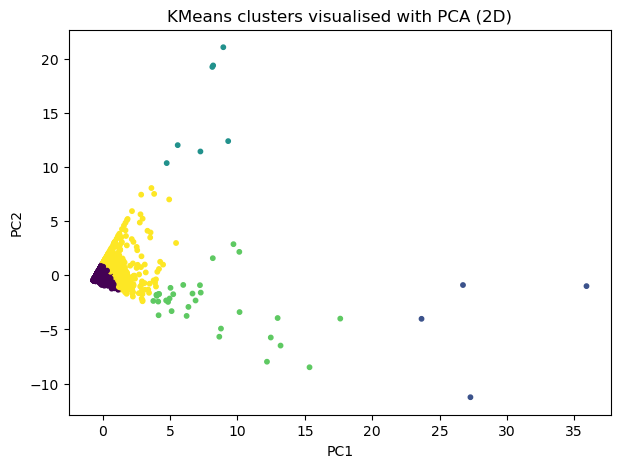

Explained variance ratio: [0.58992251 0.309681  ]


In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=customer_df["Cluster"], s=10)
plt.title("KMeans clusters visualised with PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

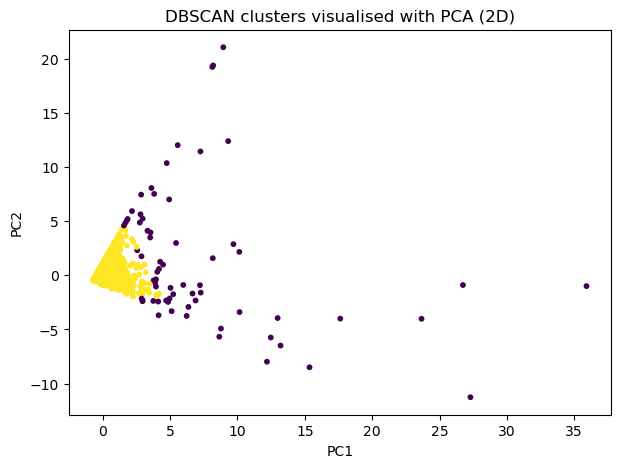

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=customer_df["DBSCAN_Cluster"],
            s=10)

plt.title("DBSCAN clusters visualised with PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Evaluation and Interpretation**

**Interpretation of KMeans Clusters**

The 5-cluster KMeans solution reveals meaningful behavioural differences between customers.

1. Cluster 0 (largest group):
Customers in this cluster exhibit relatively low total spending, low transaction frequency, and moderate basket value. This represents the core mass of casual or low-to-moderate customers.

2. Cluster 4 (mid-sized group):
These customers demonstrate higher total spend and higher transaction frequency compared to Cluster 0. They represent more engaged or loyal customers.

3. Cluster 3 (small group):
Characterised by high transaction frequency and substantial total spend, suggesting frequent heavy purchasers.


5. Cluster 2 (very small group):
These customers show high total spend but relatively low transaction frequency, combined with very high average basket value. This indicates bulk or high-value per-visit purchasers.

6. Cluster 1 (smallest group):
Extreme high-spend, high-frequency customers. This cluster captures VIP or exceptional behavioural outliers.

Overall, the segmentation highlights strong heterogeneity in purchasing behaviour, particularly at the high end of spending.

**Cluster Balance**

The clusters are highly imbalanced. The majority of customers fall into a single large cluster, while several clusters contain only a small number of customers.

However, this imbalance reflects the skewed nature of retail data, where a small number of customers often contribute disproportionately to total revenue. Therefore, the imbalance is not necessarily a modelling flaw but a structural characteristic of the dataset.


**DBSCAN Interpretation**

DBSCAN identified one dominant dense cluster and 68 noise points. These noise points likely correspond to extreme high-spend customers.

This suggests that the dataset consists of a large dense central customer base with a small number of behavioural outliers, rather than multiple equally dense segments.

Compared to KMeans, DBSCAN does not force artificial partitions but instead highlights the natural density structure of the data.


**Limitations of the Approach**

Several limitations should be acknowledged:

1. Feature Selection:
Only three behavioural features were used (total spend, transaction frequency, and average basket value). Additional variables such as recency or product diversity could improve segmentation.

2. Skewed Distribution:
The heavy-tailed spending distribution influences clustering results, particularly for distance-based methods like KMeans.

3. Algorithm Assumptions:
KMeans assumes spherical clusters of similar variance, which may not fully reflect the underlying behavioural structure.

5. Exploratory Nature:
This analysis is exploratory and does not validate clusters against external business outcomes.


**Sensitivity to Parameter Choices**

The results are sensitive to parameter selection:

**KMeans:**
Changing the number of clusters significantly alters segmentation.
Using 3 clusters led to under-segmentation, while 10 clusters resulted in over-segmentation and fragmented micro-clusters.
Five clusters provided a balanced and interpretable solution.

**DBSCAN:**
Results depend on the choice of eps and min_samples.
Different values may classify more or fewer points as noise.

This sensitivity highlights the importance of thoughtful parameter selection and interpretation rather than blindly optimising metrics.